In [38]:
import pandas as pd
import re # library called regular expresions that helps to search, match, and manipulate strings using patterns.
import nltk # library called natural language toolkit that allows us to tokenize, classify and clean language data.
from nltk.corpus import stopwords # for preprocessing
from nltk.stem import WordNetLemmatizer # for preprocessing
from transformers import RobertaTokenizerFast, AutoModel, AutoConfig, PreTrainedModel, TrainingArguments, Trainer, EarlyStoppingCallback
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,  classification_report, confusion_matrix
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset # allows to create a class object dataset
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# Set device
def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, "
        "if possible, in the menu under `Runtime` -> "
        "`Change runtime type.`  select `GPU` ")
  else:
    print("GPU is enabled in this notebook.")

  return device

DEVICE = set_device()

GPU is enabled in this notebook.


In [5]:
# Load the dataset
url = 'https://raw.githubusercontent.com/pinchunc/NMA_DL_SentimentAnalysis/main/data/hippoCorpusV2.csv'
df = pd.read_csv(url)
df = df[['story', 'memType', 'stressful']].dropna() # we exclude n/a spaces
df.head()

,story,memType,stressful
0,"Concerts are my most favorite thing, and my bo...",imagined,1.0
1,"The day started perfectly, with a great drive ...",recalled,1.0
2,It seems just like yesterday but today makes f...,imagined,1.0
3,"Five months ago, my niece and nephew were born...",recalled,2.0
4,About a month ago I went to burning man. I was...,imagined,4.0


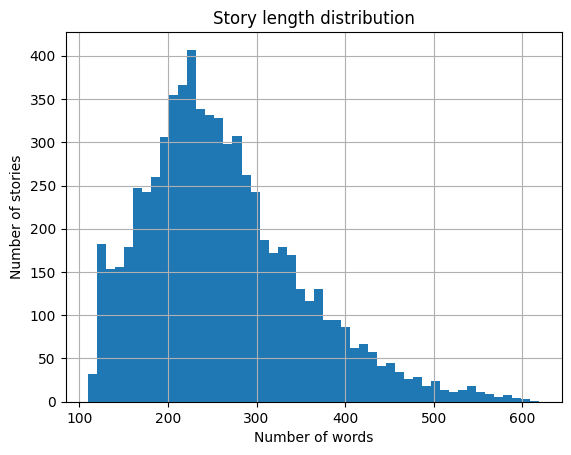

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


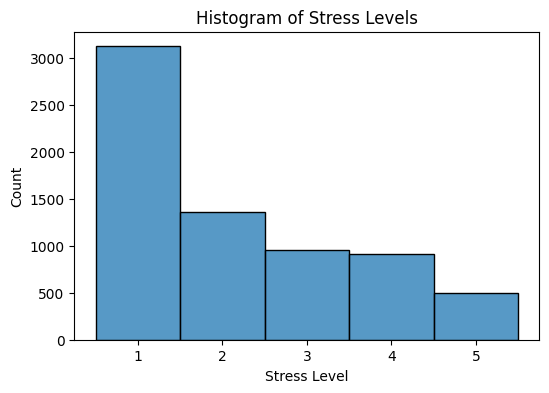

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


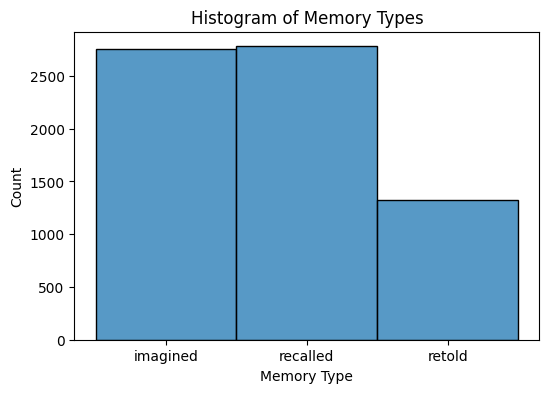

Word Count Average = 262.616574263204
stressful
1.0    3125
2.0    1363
3.0     956
4.0     908
5.0     502
Name: count, dtype: int64
memType
recalled    2779
imagined    2756
retold      1319
Name: count, dtype: int64


In [6]:
# @title Exploratory Data Analysis

# Count number of words in each story
df['word_count'] = df['story'].astype(str).apply(lambda x: len(x.split()))
word_count_average = df['word_count'].mean()

# Plot distribution of word count
df['word_count'].hist(bins=50)
plt.xlabel("Number of words")
plt.ylabel("Number of stories")
plt.title("Story length distribution")
plt.show()

# Plot distribution of stress levels
plt.figure(figsize=(6, 4))
sns.histplot(df['stressful'], discrete=True, kde=False)
plt.title('Histogram of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

# Plot distribution of memory types
plt.figure(figsize=(6, 4))
sns.histplot(df['memType'], discrete=True, kde=False)
plt.title('Histogram of Memory Types')
plt.xlabel('Memory Type')
plt.ylabel('Count')
plt.show()

print(f"Word Count Average = {word_count_average}")
print(df['stressful'].value_counts().sort_index())
print(df['memType'].value_counts())

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


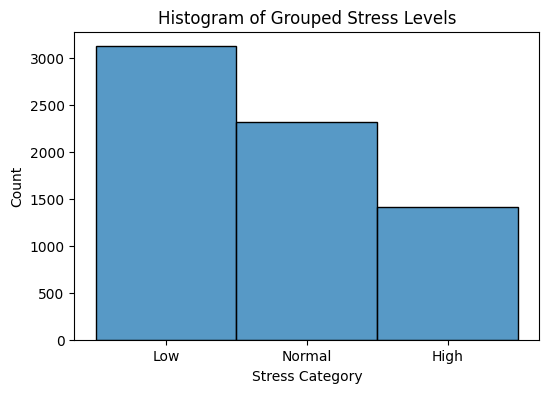

Unique values in original 'stressful' column: [1. 2. 4. 3. 5.]
Unique values in new 'stress_label' column: [0 1 2]


In [7]:
# @title Relabel Stress Levels
def relabel_stress(level):
  if level == 1:
    return 0
  elif level in [2, 3]:
    return 1
  else:
    return 2

df['stress_label'] = df['stressful'].apply(relabel_stress)

# Plot new grouped stress levels
plt.figure(figsize=(6, 4))
sns.histplot(df['stress_label'], discrete=True, kde=False)
plt.title('Histogram of Grouped Stress Levels')
plt.xlabel('Stress Category')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Low', 'Normal', 'High'])
plt.show()

print("Unique values in original 'stressful' column:", df['stressful'].unique())
print("Unique values in new 'stress_label' column:", df['stress_label'].unique())

In [8]:
# @title 1) Preprocessing
# Minimal cleaning because we are using DistilRoberta that is trained already in raw unnormalised data
def minimal_clean(text):
    text = str(text)                              # 1) Ensure it's a string
    text = re.sub(r'\s+', ' ', text)              # 2) Replace multiple spaces/newlines with a single space
    text = text.strip()                           # 3) Trim leading/trailing whitespace
    return text

df["clean_story"] = df["story"].apply(minimal_clean)

# Minimal preprocessing for RoBERTa using pandas (faster)
# df['story'] = df['story'].astype(str).fillna('').str.strip()

# Encode labels as intergers for classification
df['stress_label'] = df['stress_label'].astype(int)

In [9]:
# @title 2) Tokenization with DistilRoberta tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained('distilroberta-base')

# Tokenize only first "max_length" words of each story (truncate if they exceed the word limit and pad to mantain length of stories consistent)
tokens = tokenizer(list(df['clean_story']), truncation=True, padding='max_length', max_length=400)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

In [10]:
# @title 3) Create Class Object
# Create an object of class StressDataset to use Hugging Face's 'Trainer'
class StressDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=400):
      """
        texts: list or array of input texts (cleaned stories)
        labels: list or array of corresponding stress level labels
        tokenizer: Hugging Face DestilRoberta Tokenizer
        max_len: max length of tokenized input (default = 400 tokens)
      """

      self.texts = texts
      self.labels = labels
      self.tokenizer = tokenizer
      self.max_len = max_len

    def __getitem__(self, idx):
        encoding = self.tokenizer(    # tokenize the text
            self.texts[idx],          # retrieves the story text at index 'idx'
            truncation=True,          # cuts the input off it it exceeds max_len
            padding='max_length',     # pads the input up to max_len tokens
            max_length=self.max_len,  # sets the maximum length of tokens
            return_tensors='pt'       # Returns tensors in PyTorch format
        )

        # This diccionary with token IDs, masks for padding and labels of stress levels
        return {
            'input_ids': encoding['input_ids'].squeeze(),               # token IDs of the story text
            'attention_mask': encoding['attention_mask'].squeeze(),     # binary mask (1s and 0s) telling the model which tokens are content and which are padding.
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)  # retrieves the corresponding label of the story at index 'idx' and converts it into a PyTorch tensor with interger type (long) for classification
        }

    def __len__(self):
        return len(self.texts) # this returns the number of stories in the dataset

In [11]:
# @title 4) Split the dataset (training, validation and testing)

texts = df["clean_story"]
labels = df["stress_label"]

# Step 1: Split into 80% train and 20% temp (for val + test)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(splitter.split(texts, labels))

train_texts   = [texts[i] for i in train_idx]
train_labels  = [labels[i] for i in train_idx]
temp_texts    = [texts[i] for i in temp_idx]
temp_labels   = [labels[i] for i in temp_idx]

# Step 2: Split temp into 50% val and 50% test → 10% each of the full dataset
splitter_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(splitter_val.split(temp_texts, temp_labels))

val_texts = [temp_texts[i] for i in val_idx]
val_labels = [temp_labels[i] for i in val_idx]
test_texts = [temp_texts[i] for i in test_idx]
test_labels = [temp_labels[i] for i in test_idx]

# Build datasets
train_dataset = StressDataset(train_texts, train_labels, tokenizer)
val_dataset = StressDataset(val_texts, val_labels, tokenizer)
test_dataset = StressDataset(test_texts, test_labels, tokenizer)

In [12]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=[0, 1, 2],
    y=train_labels
)

weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print("Class weights:", weights)

Class weights: tensor([0.7311, 0.9853, 1.6203], device='cuda:0')


In [48]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # class weights
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        if self.alpha is not None and not isinstance(self.alpha, torch.Tensor):
            self.alpha = torch.tensor(self.alpha, dtype=torch.float, device=DEVICE)
            
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)  # predicted prob of the true class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [64]:
# @title 5) Define Custom DistilRoberta Model with Hidden Layer
class DistilRobertaClassifier(PreTrainedModel):
    def __init__(self, config, class_weights=None):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.class_weights = class_weights
        self.distilroberta = AutoModel.from_pretrained("distilroberta-base", config=config) # DistilRoberta model

        self.hidden_size = config.hidden_size
        self.lstm_hidden_size = 128
        
        # Bidirectional LSTM
        self.bi_lstm = nn.LSTM(
            input_size=self.hidden_size,
            hidden_size=self.lstm_hidden_size,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        # Fully connected layers
        self.pre_classifier = nn.Linear(self.lstm_hidden_size * 2, 256)
        self.relu = nn.ReLU() # ReLU
        self.dropout = nn.Dropout(0.3) # regularisation
        self.classifier = nn.Linear(256, 3)  # 3 output classes

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.distilroberta(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)
        
        # LSTM layer
        lstm_output, _ = self.bi_lstm(hidden_state)

        # Mean pooling to capture the meaning of the story
        pooled_output = torch.mean(lstm_output, dim=1)
        
        # Feedforward classifier
        x = self.pre_classifier(pooled_output)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)
            loss = loss_fn(logits, labels)

        if loss is not None:
            loss = loss.unsqueeze(0)  # Adds batch dimension

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits
        )

In [65]:
# @title 6) Define Model: DistilRoberta
# DistilRoberta Model with 3 labels for classification
config = AutoConfig.from_pretrained(
    'distilroberta-base',
    num_labels=3,
)

model = DistilRobertaClassifier(config)

In [66]:
# @title 7) Define Evaluation Metrics
# Evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids               # true labels
    preds = pred.predictions.argmax(-1)   # from the predictions (logits), it picks the index of the class with the highest predicted score.

    # Print predicted vs true label distribution
    print("Predicted label distribution:", np.bincount(preds))
    print("True label distribution:", np.bincount(labels))

    # Per-class metrics report
    print("\n Classification report:\n", classification_report(labels, preds, digits=3)) 

    # Plot confusion matrix here
    cm = confusion_matrix(labels, preds, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Normal', 'High'],
                yticklabels=['Low', 'Normal', 'High'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Returns a diccionary so the 'Trainer' can log them
    return {
        'accuracy': accuracy_score(labels, preds),                    # Fraction of predictions that were exactly correct
        'f1_macro': f1_score(labels, preds, average='macro'),         # F1-score (combination of Precision and Recall) avg equally across all classes (not weighted by class frequency - good for imbalanced data)
        'precision': precision_score(labels, preds, average='macro'), # Precision avg across all classes
        'recall': recall_score(labels, preds, average='macro')       # Recall avg across all classes
    }

In [67]:
# @title 8) Define Training Arguments
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',         # Directory where model checkpoints and other outputs will be saved during training
    learning_rate=2e-5,             # Common starting LR for transformers
    per_device_train_batch_size=16, # Reasonable for most GPUs
    per_device_eval_batch_size=32,  # Larger batch for evaluation
    num_train_epochs=5,            # Commonly between 3 and 5
    weight_decay=0.01,              # L2 regularization: prevents overfitting by discouraging large weights

    lr_scheduler_type="linear",     # Stabilise early training, and the learning rate drops over time, preventing overshooting
    warmup_steps=200,               # gradually increases the learning rate from zero to target learning rate over a certain number of steps at the start of training
    max_grad_norm=1.0,              # to avoid LSTM gradients to explode
    
    # Training loss
    logging_strategy="steps",
    logging_steps=200,              # Log training loss and metrics every 100 steps

    # Evaluation metrics
    eval_strategy="steps",
    eval_steps=200,                # Evaluate every 100 steps

    # Save model
    save_strategy="steps",
    save_steps=200,
    save_total_limit=1,             # Keeps only 1 checkpoint in the output_dir, deleting older ones to control disk usage

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir='./logs',           # Directory where log files will be written
    report_to='none',               # disable wanb
)

In [68]:
# @title 9) Define Trainer
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

/tmp/ipykernel_36/3050782088.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
200,0.504600,0.475203,0.392701,0.388082,0.477439,0.440618
400,0.469000,0.458126,0.521168,0.494382,0.493290,0.512327
600,0.430800,0.476798,0.519708,0.500620,0.498475,0.505111
800,0.398200,0.488487,0.500730,0.487735,0.494060,0.488606


Predicted label distribution: [ 83 355 247]
True label distribution: [312 232 141]

 Classification report:
               precision    recall  f1-score   support

           0      0.747     0.199     0.314       312
           1      0.349     0.534     0.422       232
           2      0.336     0.589     0.428       141

    accuracy                          0.393       685
   macro avg      0.477     0.441     0.388       685
weighted avg      0.528     0.393     0.374       685



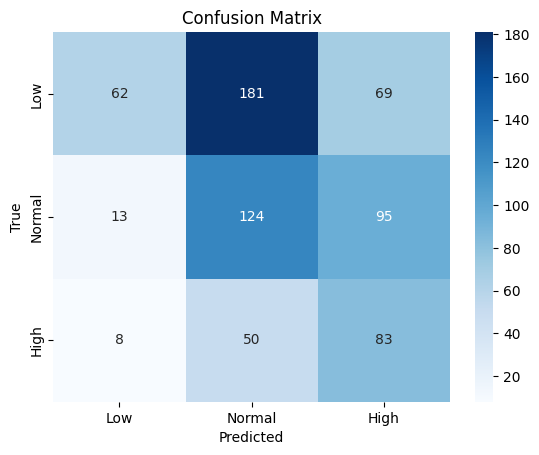

Predicted label distribution: [303 174 208]
True label distribution: [312 232 141]

 Classification report:
               precision    recall  f1-score   support

           0      0.670     0.651     0.660       312
           1      0.425     0.319     0.365       232
           2      0.385     0.567     0.458       141

    accuracy                          0.521       685
   macro avg      0.493     0.512     0.494       685
weighted avg      0.528     0.521     0.519       685



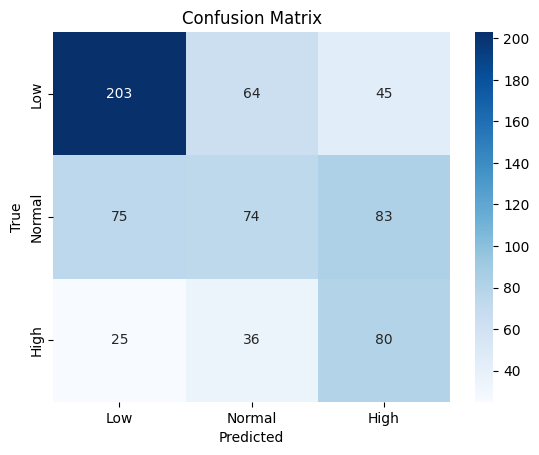

Predicted label distribution: [289 232 164]
True label distribution: [312 232 141]

 Classification report:
               precision    recall  f1-score   support

           0      0.661     0.612     0.636       312
           1      0.414     0.414     0.414       232
           2      0.421     0.489     0.452       141

    accuracy                          0.520       685
   macro avg      0.498     0.505     0.501       685
weighted avg      0.528     0.520     0.523       685



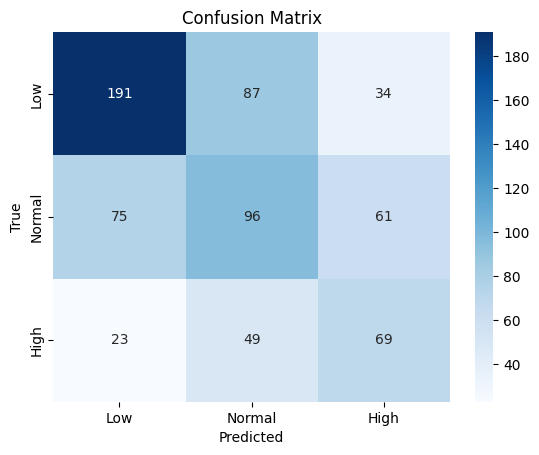

Predicted label distribution: [254 282 149]
True label distribution: [312 232 141]

 Classification report:
               precision    recall  f1-score   support

           0      0.669     0.545     0.601       312
           1      0.390     0.474     0.428       232
           2      0.423     0.447     0.434       141

    accuracy                          0.501       685
   macro avg      0.494     0.489     0.488       685
weighted avg      0.524     0.501     0.508       685



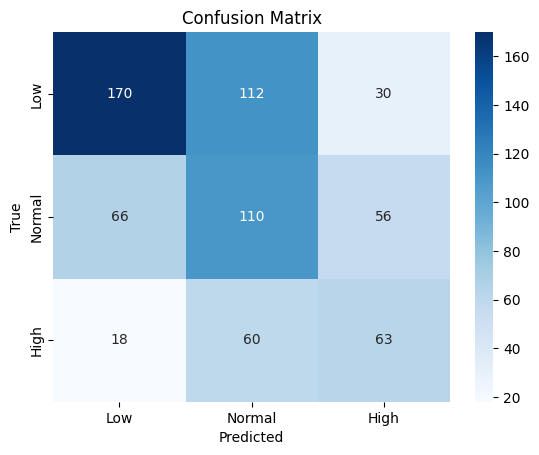

Predicted label distribution: [278 246 162]
True label distribution: [313 232 141]

 Classification report:
               precision    recall  f1-score   support

           0      0.633     0.562     0.596       313
           1      0.407     0.431     0.418       232
           2      0.420     0.482     0.449       141

    accuracy                          0.501       686
   macro avg      0.486     0.492     0.488       686
weighted avg      0.513     0.501     0.506       686



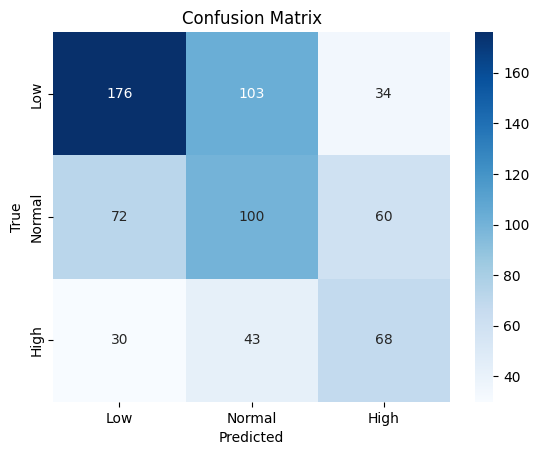

Final Test Set Results: {'eval_loss': 0.48881280422210693, 'eval_accuracy': 0.5014577259475219, 'eval_f1_macro': 0.4876185343828013, 'eval_precision': 0.48645022554675316, 'eval_recall': 0.49186810193117925, 'eval_runtime': 5.9275, 'eval_samples_per_second': 115.732, 'eval_steps_per_second': 1.856, 'epoch': 5.0}


In [69]:
# @title 10) Train, Validate and Evaluate Model
# Train model
trainer.train()

# Evaluate
test_results = trainer.evaluate(test_dataset)
print("Final Test Set Results:", test_results)

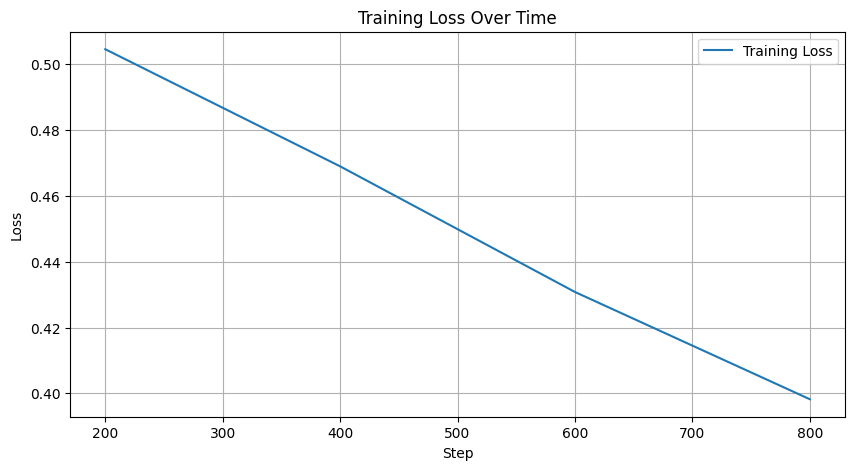

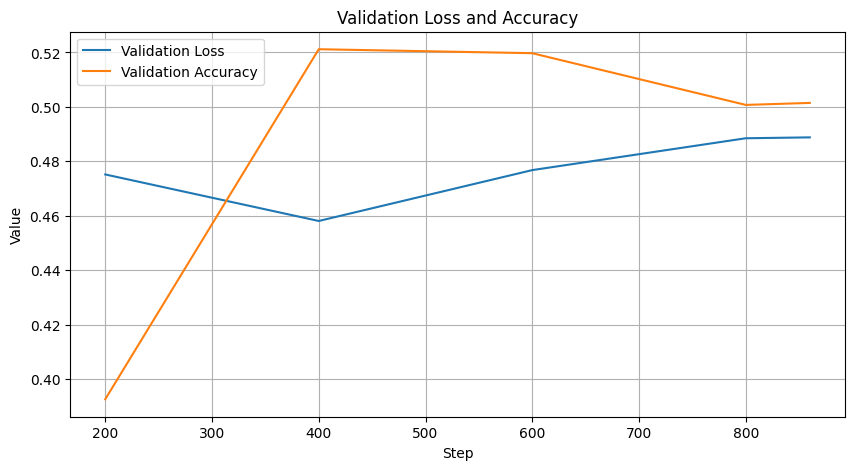

In [70]:
# @title Plot Training Loss and Validation Loss and Accuracy
# Convert logs to DataFrame
log_history = pd.DataFrame(trainer.state.log_history)

# Plot training loss
plt.figure(figsize=(10, 5))
train_logs = log_history.dropna(subset=["loss"])
plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.legend()
plt.grid()
plt.show()

# Plot validation loss and accuracy
eval_logs = log_history.dropna(subset=["eval_loss"])

plt.figure(figsize=(10, 5))
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")
if "eval_accuracy" in eval_logs.columns:
    plt.plot(eval_logs["step"], eval_logs["eval_accuracy"], label="Validation Accuracy")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("Validation Loss and Accuracy")
plt.legend()
plt.grid()
plt.show()

In [76]:
from torch.utils.data import DataLoader

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


model.eval()
embeddings = []
labels = []

for batch in val_loader:
    # Move batch to GPU
    batch = {k: v.to(DEVICE) for k, v in batch.items()}

    with torch.no_grad():
        outputs = model.distilroberta(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        cls_embedding = outputs.last_hidden_state[:, 0]  # (batch_size, hidden_size)
        embeddings.append(cls_embedding.cpu())  # Move to CPU for later visualization
        labels.extend(batch['labels'].cpu())    # Same here


/usr/local/lib/python3.11/dist-packages/numpy/lib/arraysetops.py:733: RuntimeWarning: invalid value encountered in equal
  mask |= (ar1 == a)
/usr/local/lib/python3.11/dist-packages/numpy/lib/arraysetops.py:733: RuntimeWarning: invalid value encountered in equal
  mask |= (ar1 == a)
/usr/local/lib/python3.11/dist-packages/numpy/lib/arraysetops.py:733: RuntimeWarning: invalid value encountered in equal
  mask |= (ar1 == a)


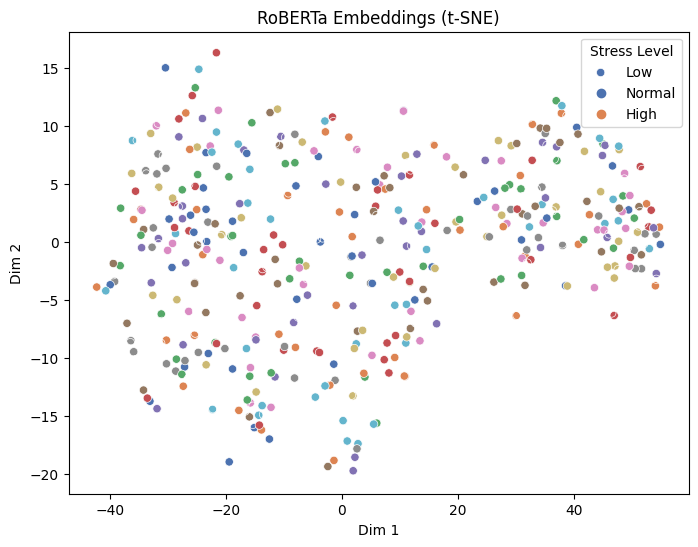

In [78]:
from sklearn.manifold import TSNE

embeddings_np = torch.cat(embeddings).numpy()  # Combine and convert to NumPy

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(embeddings_np)

plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette='deep')
plt.title("RoBERTa Embeddings (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(title="Stress Level", labels=["Low", "Normal", "High"])
plt.show()
